---
## 📦 Segment 1 — Installs & Imports

In [1]:
# ============================================================
# 1.1 — Install required packages
# ============================================================
!pip install -q transformers datasets accelerate peft bitsandbytes
!pip install -q jiwer gradio torchaudio librosa soundfile
!pip install -q evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00


In [2]:
# ============================================================
# 1.2 — Imports
# ============================================================
import os
import gc
import time
import json
import zipfile
import itertools
import warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Union

import numpy as np
import pandas as pd
import torch
import torchaudio
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader

from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    WhisperTokenizer,
    WhisperFeatureExtractor,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    EarlyStoppingCallback,
)

from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    PeftModel,
    TaskType,
)

import evaluate
from jiwer import wer, cer

warnings.filterwarnings("ignore")
print("✅ All imports successful!")

✅ All imports successful!


---
## ⚡ Segment 2 — GPU Check & Config

In [3]:
# ============================================================
# 2.1 — Verify GPU availability
# ============================================================
if not torch.cuda.is_available():
    raise RuntimeError(
        "❌ No GPU found! Go to Runtime → Change Runtime Type → T4 GPU"
    )

device = torch.device("cuda")
gpu_name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9

print(f"✅ GPU: {gpu_name}")
print(f"✅ VRAM: {vram_gb:.1f} GB")
print(f"✅ CUDA: {torch.version.cuda}")
print(f"✅ PyTorch: {torch.__version__}")

✅ GPU: Tesla T4
✅ VRAM: 15.6 GB
✅ CUDA: 12.8
✅ PyTorch: 2.10.0+cu128


In [4]:
# ============================================================
# 2.2 — Global configuration
# ============================================================
MODEL_NAME = "openai/whisper-medium"
LANGUAGE = "english"
TASK = "transcribe"
SAMPLING_RATE = 16000

# Dataset paths
DATA_DIR = Path("/content/nus-48e")
CHECKPOINT_DIR = Path("/content/checkpoints")
RESULTS_DIR = Path("/content/results")

# Create directories
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"✅ Config set — Model: {MODEL_NAME}")
print(f"   Language: {LANGUAGE} | Task: {TASK} | SR: {SAMPLING_RATE}")

✅ Config set — Model: openai/whisper-medium
   Language: english | Task: transcribe | SR: 16000


---
## 🎵 Segment 3 — Dataset Download & Preprocessing

In [5]:
# ============================================================
# 3.1 — Download NUS-48E from Zenodo
# ============================================================
import urllib.request

ZENODO_URL = "https://zenodo.org/records/19595152/files/nus-smc-corpus_48.zip"
ZIP_PATH = "/content/nus-smc-corpus_48.zip"

if not DATA_DIR.exists():
    print("📥 Downloading NUS-48E from Zenodo (~1.1 GB)...")
    print("   This may take a few minutes on Colab.")
    !wget -q --show-progress -O {ZIP_PATH} "{ZENODO_URL}"

    print("\n📦 Extracting...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall("/content/")

    # Locate the actual extracted folder
    extracted_dirs = [d for d in Path("/content").iterdir() if d.is_dir() and "nus" in d.name.lower()]
    if extracted_dirs and extracted_dirs[0] != DATA_DIR:
        extracted_dirs[0].rename(DATA_DIR)

    # Clean up zip
    os.remove(ZIP_PATH)
    print("✅ NUS-48E downloaded and extracted!")
else:
    print("✅ NUS-48E already exists, skipping download.")

# List the top-level contents
print(f"\n📁 Dataset contents ({DATA_DIR}):")
for item in sorted(DATA_DIR.iterdir()):
    print(f"   {'📂' if item.is_dir() else '📄'} {item.name}")

📥 Downloading NUS-48E from Zenodo (~1.1 GB)...
   This may take a few minutes on Colab.
/content/nus-smc-co 100%[===================>]   1.01G  18.9MB/s    in 57s     

📦 Extracting...
✅ NUS-48E downloaded and extracted!

📁 Dataset contents (/content/nus-48e):
   📂 ADIZ
   📂 JLEE
   📂 JTAN
   📂 KENN
   📂 MCUR
   📂 MPOL
   📂 MPUR
   📂 NJAT
   📂 PMAR
   📄 README.txt
   📂 SAMF
   📂 VKOW
   📂 ZHIY


In [8]:
# ============================================================
# 3.2 — Parse dataset using Spoken audio for Ground Truth labels
# ============================================================
# 🧹 Clear memory from baseline eval first
gc.collect()
torch.cuda.empty_cache()

print("♡ NUS-48E .txt files lack words. Generating ground truth labels")
print("   by transcribing the 'read' (spoken) versions using Whisper...")

# Load model and processor directly for transcription
label_model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)
label_processor = WhisperProcessor.from_pretrained(MODEL_NAME)

def parse_nus48e_with_spoken_labels(data_dir: Path) -> List[Dict]:
    samples = []
    label_model.eval()

    for speaker_dir in sorted(data_dir.iterdir()):
        if not speaker_dir.is_dir():
            continue

        sing_dir = speaker_dir / "sing"
        read_dir = speaker_dir / "read"

        if not sing_dir.exists(): sing_dir = speaker_dir / "SING"
        if not read_dir.exists(): read_dir = speaker_dir / "READ"

        if not sing_dir.exists() or not read_dir.exists():
            continue

        for sing_wav in sorted(sing_dir.glob("*.wav")):
            read_wav = read_dir / sing_wav.name

            if read_wav.exists():
                speech_array, _ = librosa.load(str(read_wav), sr=16000)

                input_features = label_processor(
                    speech_array, sampling_rate=16000, return_tensors="pt"
                ).input_features.to(device).float()

                with torch.no_grad():
                    predicted_ids = label_model.generate(
                        input_features=input_features,  # ✅ Fix: keyword arg
                        language="english",
                        task="transcribe"
                    )

                transcription = label_processor.batch_decode(
                    predicted_ids, skip_special_tokens=True
                )[0].strip().lower()

                if transcription:
                    samples.append({
                        "audio_path": str(sing_wav),
                        "lyrics": transcription,
                        "speaker": speaker_dir.name,
                        "song_id": sing_wav.stem,
                    })

    return samples

all_samples = parse_nus48e_with_spoken_labels(DATA_DIR)
print(f"✅ Found {len(all_samples)} singing samples with spoken English labels!")

for s in all_samples[:3]:
    print(f"   ♡ [{s['speaker']}] {s['song_id']}: \"{s['lyrics'][:80]}...\"")

del label_model
del label_processor
gc.collect()
torch.cuda.empty_cache()
print("ဒ Labeling model cleaned up. VRAM freed.")

♡ NUS-48E .txt files lack words. Generating ground truth labels
   by transcribing the 'read' (spoken) versions using Whisper...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.06G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

...

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensA

✅ Found 48 singing samples with spoken English labels!
   ♡ [ADIZ] 01: "edelweiss, edelweiss, every morning you greet me, small and white, clean and bri..."
   ♡ [ADIZ] 09: "love me tender, love me sweet, never let me go. you have made my life complete a..."
   ♡ [ADIZ] 13: "love in your eyes, sitting silent by my side, going on holding hands, walking th..."
ဒ Labeling model cleaned up. VRAM freed.


In [9]:
# ============================================================
# 3.3 — Leave-One-Speaker-Out (LOSO) split
# ============================================================
# WHY: NUS-48E has 12 speakers × 4 songs = 48 samples.
# A random 80/10/10 split gives only 5 test samples — statistically
# meaningless. Worse, the same songs appear in both train and test
# (just different singers), which inflates fine-tuned WER scores.
#
# LOSO fix: hold out ONE full speaker as test, use another as val,
# train on the remaining 10. This gives ~4 test samples per fold
# but they are from a completely unseen speaker AND unseen voice,
# making the evaluation genuinely honest.
#
# For a single-run experiment, we pick a fixed held-out test speaker
# and a fixed val speaker. To report robust results, rotate through
# all 12 speakers (full LOSO) — see the optional loop at the bottom.

# ── Pick held-out speakers ────────────────────────────────────────────────────
all_speakers = sorted(set(s["speaker"] for s in all_samples))
print(f"📋 All speakers ({len(all_speakers)}): {all_speakers}")

# Hold out last speaker alphabetically as test, second-to-last as val
# Change these to any two speakers you prefer.
TEST_SPEAKER = all_speakers[-1]     # e.g. "ZHIY"
VAL_SPEAKER  = all_speakers[-2]     # e.g. "VKOW"

train_samples = [s for s in all_samples if s["speaker"] not in (TEST_SPEAKER, VAL_SPEAKER)]
val_samples   = [s for s in all_samples if s["speaker"] == VAL_SPEAKER]
test_samples  = [s for s in all_samples if s["speaker"] == TEST_SPEAKER]

print(f"\n📊 LOSO Split:")
print(f"   Train : {len(train_samples)} samples  ({len(all_speakers)-2} speakers)")
print(f"   Val   : {len(val_samples)} samples  (speaker: {VAL_SPEAKER})")
print(f"   Test  : {len(test_samples)} samples  (speaker: {TEST_SPEAKER}  ← fully unseen)")

# Sanity check — no song-level leakage from test speaker into train
test_song_ids = {s["song_id"] for s in test_samples}
train_song_ids = {s["song_id"] for s in train_samples}
overlap = test_song_ids & train_song_ids
if overlap:
    print(f"\n   ℹ️  Song ID overlap (same songs, different singers): {overlap}")
    print(f"      This is expected — model sees the melody but never this speaker's voice.")
else:
    print(f"\n   ✅ No song ID overlap between train and test.")

# ── Optional: Full LOSO loop (12-fold cross-validation) ──────────────────────
# Uncomment and run this instead of the single split above for robust results.
#
# loso_results = []
# for test_spk in all_speakers:
#     val_spk = [s for s in all_speakers if s != test_spk][-1]
#     tr = [s for s in all_samples if s["speaker"] not in (test_spk, val_spk)]
#     vl = [s for s in all_samples if s["speaker"] == val_spk]
#     te = [s for s in all_samples if s["speaker"] == test_spk]
#     loso_results.append({"test_speaker": test_spk, "train": tr, "val": vl, "test": te})
#     print(f"Fold: test={test_spk}, val={val_spk}, train_n={len(tr)}")

📋 All speakers (12): ['ADIZ', 'JLEE', 'JTAN', 'KENN', 'MCUR', 'MPOL', 'MPUR', 'NJAT', 'PMAR', 'SAMF', 'VKOW', 'ZHIY']

📊 LOSO Split:
   Train : 40 samples  (10 speakers)
   Val   : 4 samples  (speaker: VKOW)
   Test  : 4 samples  (speaker: ZHIY  ← fully unseen)

   ℹ️  Song ID overlap (same songs, different singers): {'02', '03', '06', '14'}
      This is expected — model sees the melody but never this speaker's voice.


In [10]:
# ============================================================
# 3.4 — Load Whisper processor and create PyTorch Dataset
# ============================================================
processor = WhisperProcessor.from_pretrained(
    MODEL_NAME, language=LANGUAGE, task=TASK
)
tokenizer = processor.tokenizer
feature_extractor = processor.feature_extractor

print(f"✅ Processor loaded: {MODEL_NAME}")


class NUS48EDataset(Dataset):
    """PyTorch Dataset for NUS-48E singing samples."""

    def __init__(self, samples: List[Dict], processor, sampling_rate: int = 16000):
        self.samples = samples
        self.processor = processor
        self.sampling_rate = sampling_rate

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Load and resample audio
        audio, sr = librosa.load(
            sample["audio_path"], sr=self.sampling_rate, mono=True
        )

        # Compute log-Mel spectrogram features
        input_features = self.processor.feature_extractor(
            audio, sampling_rate=self.sampling_rate, return_tensors="np"
        ).input_features[0]

        # Tokenize lyrics
        labels = self.processor.tokenizer(
            sample["lyrics"],
            return_tensors="np",
            padding=False,
            truncation=True,
            max_length=448,
        ).input_ids[0]

        return {
            "input_features": input_features,
            "labels": labels,
        }


# Create datasets
train_dataset = NUS48EDataset(train_samples, processor, SAMPLING_RATE)
val_dataset = NUS48EDataset(val_samples, processor, SAMPLING_RATE)
test_dataset = NUS48EDataset(test_samples, processor, SAMPLING_RATE)

print(f"✅ Datasets created — Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

✅ Processor loaded: openai/whisper-medium
✅ Datasets created — Train: 40, Val: 4, Test: 4


In [11]:
# ============================================================
# 3.5 — Data Collator for Whisper
# ============================================================
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    """
    Data collator that pads input features and labels for Whisper.
    Labels are padded with -100 so they are ignored in loss computation.
    """
    processor: Any
    decoder_start_token_id: int = None

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": feature["labels"]} for feature in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        # Replace padding token id with -100 for loss masking
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        # Safely remove BOS token if it was appended
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch

---
## 🧠 Segment 4 — Model + LoRA Setup

In [13]:
# Fix: upgrade torchao to compatible version
!pip install -q "torchao>=0.16.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 46.2 MB/s eta 0:00:00


In [15]:
# ============================================================
# 4.1 — Two LoRA configurations: decoder-only vs encoder+decoder
# ============================================================
# The spec requires both as separate experiments so you can
# compare them. Key difference:
#
#   Decoder-only  → LoRA on cross-attention + self-attention in decoder
#                   Encoder weights frozen completely
#                   Fewer trainable params, faster, often sufficient
#
#   Encoder+Dec   → LoRA on both sides
#                   More params, slower, can help if singing changes
#                   acoustic features significantly (pitch, rhythm)

def load_model_with_lora(
    model_name: str,
    processor,
    lora_r: int = 8,
    lora_alpha: int = 32,
    lora_dropout: float = 0.05,
    decoder_only: bool = False,       # ← NEW parameter
) -> tuple:

    model = WhisperForConditionalGeneration.from_pretrained(
        model_name,
        torch_dtype=torch.float32,
        device_map={"": 0},
    )

    model.config.use_cache = False
    model.generation_config.language = "english"
    model.generation_config.task = "transcribe"
    model.generation_config.forced_decoder_ids = None
    model.generation_config.suppress_tokens = []

    # Apply LoRA to q_proj and v_proj across the whole model first
    lora_config = LoraConfig(
        r=lora_r,
        lora_alpha=lora_alpha,
        target_modules=["q_proj", "v_proj"],
        lora_dropout=lora_dropout,
        bias="none",
        task_type=TaskType.SEQ_2_SEQ_LM,
    )
    model = get_peft_model(model, lora_config)

    # ── Decoder-only mode: freeze encoder LoRA weights ───────────────────────
    # PEFT applies LoRA to both encoder and decoder when target_modules matches
    # both. To isolate decoder-only, we freeze the encoder LoRA params after
    # the fact — they exist but won't receive gradients.
    if decoder_only:
        frozen = 0
        for name, param in model.named_parameters():
            if "model.encoder" in name and "lora_" in name:
                param.requires_grad = False
                frozen += param.numel()
        print(f"   🔒 Frozen {frozen:,} encoder LoRA params (decoder-only mode)")

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())

    return model, trainable, total


# ── Quick verification ────────────────────────────────────────────────────────
print("🔍 Decoder-only LoRA:")
m_dec, tr_dec, tot = load_model_with_lora(MODEL_NAME, processor, lora_r=8, decoder_only=True)
print(f"   Trainable: {tr_dec:,}  ({100*tr_dec/tot:.3f}%)")
del m_dec; gc.collect(); torch.cuda.empty_cache()

print("\n🔍 Encoder + Decoder LoRA:")
m_both, tr_both, tot = load_model_with_lora(MODEL_NAME, processor, lora_r=8, decoder_only=False)
print(f"   Trainable: {tr_both:,}  ({100*tr_both/tot:.3f}%)")
del m_both; gc.collect(); torch.cuda.empty_cache()

print(f"\n📊 Param difference: {tr_both - tr_dec:,} extra params when encoder is included")

🔍 Decoder-only LoRA:


Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

   🔒 Frozen 786,432 encoder LoRA params (decoder-only mode)
   Trainable: 1,572,864  (0.205%)

🔍 Encoder + Decoder LoRA:


Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

   Trainable: 2,359,296  (0.308%)

📊 Param difference: 786,432 extra params when encoder is included


In [16]:
# ============================================================
# 4.2 — Quick test: load model and show parameter counts
# ============================================================
test_model, trainable, total = load_model_with_lora(MODEL_NAME, processor, lora_r=8, lora_alpha=32)

print(f"\n📊 Parameter Summary:")
print(f"   Total params:     {total:>12,}")
print(f"   Trainable params: {trainable:>12,}")
print(f"   Trainable %:      {100 * trainable / total:.2f}%")

# Print LoRA module names
print(f"\n🔧 LoRA modules:")
test_model.print_trainable_parameters()

# Clean up test model
del test_model
gc.collect()
torch.cuda.empty_cache()
print("\n✅ Test model cleaned up.")

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]


📊 Parameter Summary:
   Total params:      766,217,216
   Trainable params:    2,359,296
   Trainable %:      0.31%

🔧 LoRA modules:
trainable params: 2,359,296 || all params: 766,217,216 || trainable%: 0.3079

✅ Test model cleaned up.


---
## 📏 Segment 5 — Zero-Shot Baseline Evaluation

In [17]:
import evaluate
from jiwer import wer, cer

# ============================================================
# 5.1 — Compute metrics helper
# ============================================================
wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

def compute_metrics_from_pred(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    if isinstance(pred_ids, tuple):
        pred_ids = pred_ids[0]

    label_ids = np.where(label_ids != -100, label_ids, tokenizer.pad_token_id)

    pred_str = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    pred_str = [p.strip().lower() for p in pred_str]
    label_str = [l.strip().lower() for l in label_str]

    pred_str = [p if p else "[empty]" for p in pred_str]
    label_str = [l if l else "[empty]" for l in label_str]

    wer_val = 100 * wer_metric.compute(predictions=pred_str, references=label_str)
    cer_val = 100 * cer_metric.compute(predictions=pred_str, references=label_str)

    return {"wer": wer_val, "cer": cer_val}

def evaluate_model_on_test(
    model, test_dataset, processor, batch_size=4
) -> dict:
    model.eval()
    all_preds = []
    all_refs = []

    torch.cuda.reset_peak_memory_stats()
    start_time = time.time()

    # Ensure we use the adapter if it exists (PEFT compatibility)
    is_peft = hasattr(model, "active_adapter")

    with torch.no_grad():
        for i in range(len(test_dataset)):
            sample = test_dataset[i]
            input_features = torch.tensor(
                sample["input_features"]
            ).unsqueeze(0).to(device).float()

            # generate() params for fine-tuned models
            gen_kwargs = {
                "input_features": input_features,
                "max_new_tokens": 444,
                "language": "english",
                "task": "transcribe"
            }

            # If it's a PEFT model, ensure the adapter is specifically utilized
            if is_peft:
                predicted_ids = model.generate(**gen_kwargs)
            else:
                predicted_ids = model.generate(**gen_kwargs)

            pred_text = processor.batch_decode(
                predicted_ids, skip_special_tokens=True
            )[0].strip().lower()

            ref_text = processor.tokenizer.decode(
                sample["labels"], skip_special_tokens=True
            ).strip().lower()

            all_preds.append(pred_text)
            all_refs.append(ref_text)

    total_time = time.time() - start_time
    peak_vram = torch.cuda.max_memory_allocated() / 1e9

    wer_val = 100 * wer_metric.compute(predictions=all_preds, references=all_refs)
    cer_val = 100 * cer_metric.compute(predictions=all_preds, references=all_refs)

    return {
        "wer": round(wer_val, 2),
        "cer": round(cer_val, 2),
        "latency_s": round(total_time, 2),
        "avg_latency_s": round(total_time / len(test_dataset), 2),
        "peak_vram_gb": round(peak_vram, 2),
        "predictions": all_preds,
        "references": all_refs,
    }

print("✅ Evaluation helpers updated with PEFT safety.")

✅ Evaluation helpers updated with PEFT safety.


In [18]:
# ============================================================
# 5.2 — Run zero-shot Whisper baseline on test set
# ============================================================
print("🔄 Loading base Whisper-medium for zero-shot baseline...")

base_model = WhisperForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32,   # ✅ Fixed: was float16
    device_map={"": 0},
)

base_model.generation_config.language = "english"
base_model.generation_config.task = "transcribe"
base_model.generation_config.forced_decoder_ids = None
base_model.generation_config.suppress_tokens = []

print("🧪 Running zero-shot evaluation on test set...")
baseline_results = evaluate_model_on_test(base_model, test_dataset, processor)

print(f"\n📊 Zero-Shot Baseline Results:")
print(f"   WER:          {baseline_results['wer']:.2f}%")
print(f"   CER:          {baseline_results['cer']:.2f}%")
print(f"   Latency:      {baseline_results['latency_s']:.2f}s total")
print(f"   Avg Latency:  {baseline_results['avg_latency_s']:.2f}s/sample")
print(f"   Peak VRAM:    {baseline_results['peak_vram_gb']:.2f} GB")

print(f"\n🎤 Sample predictions (first 3):")
for i in range(min(3, len(baseline_results['predictions']))):
    print(f"   REF: {baseline_results['references'][i][:80]}")
    print(f"   PRD: {baseline_results['predictions'][i][:80]}")
    print()

del base_model
gc.collect()
torch.cuda.empty_cache()
print("✅ Baseline done, model cleaned up.")


🔄 Loading base Whisper-medium for zero-shot baseline...


Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

🧪 Running zero-shot evaluation on test set...


Both `max_new_tokens` (=444) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=444) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=444) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=444) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📊 Zero-Shot Baseline Results:
   WER:          65.54%
   CER:          56.37%
   Latency:      9.72s total
   Avg Latency:  2.43s/sample
   Peak VRAM:    6.56 GB

🎤 Sample predictions (first 3):
   REF: dou, a deer, a female deer, re, a job of golden sun, mi, a name i call myself, f
   PRD: [singing]

   REF: dashing through the snow in a one-horse open sleigh, o'er the fields we go laugh
   PRD: dashing through the snow in a one-horse open sleigh, o'er the fields we go, laug

   REF: moon river, wider than a mile, i'm crossing you in style someday. you dream make
   PRD: (singing)

✅ Baseline done, model cleaned up.


---
## 🏋️ Segment 6 — GridSearch Training

In [19]:
# ============================================================
# 6.1 — Updated GridSearch — runs BOTH configs for comparison
# ============================================================
# We run the best hyperparams found earlier with each LoRA mode
# so the comparison is apples-to-apples (same lr, r, alpha).

BEST_LORA_R     = 32
BEST_LORA_ALPHA = 32
BEST_LR         = 2e-3
BATCH_SIZE      = 2
NUM_EPOCHS      = 15

experiments = [
    {"name": "decoder_only",    "decoder_only": True},
    {"name": "encoder_decoder", "decoder_only": False},
]

comparison_results = []

for exp in experiments:
    print(f"\n{'='*60}")
    print(f"⌛ Experiment: {exp['name']}")
    print(f"{'='*60}")

    run_dir = CHECKPOINT_DIR / exp["name"]

    model, trainable_params, total_params = load_model_with_lora(
        MODEL_NAME, processor,
        lora_r=BEST_LORA_R,
        lora_alpha=BEST_LORA_ALPHA,
        decoder_only=exp["decoder_only"],
    )
    model.gradient_checkpointing_enable()

    print(f"   Trainable params: {trainable_params:,} ({100*trainable_params/total_params:.3f}%)")

    data_collator = DataCollatorSpeechSeq2SeqWithPadding(
        processor=processor,
        decoder_start_token_id=model.config.decoder_start_token_id,
    )

    training_args = Seq2SeqTrainingArguments(
        output_dir=str(run_dir),
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=4,
        learning_rate=BEST_LR,
        warmup_steps=5,
        num_train_epochs=NUM_EPOCHS,
        fp16=True,
        eval_strategy="no",
        save_strategy="no",
        logging_steps=10,
        predict_with_generate=True,
        generation_max_length=225,
        report_to="none",
        seed=SEED,
        remove_unused_columns=False,
        label_names=["labels"],
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        data_collator=data_collator,
        processing_class=processor,
    )

    train_result = trainer.train()
    model.eval()

    test_metrics = evaluate_model_on_test(model, test_dataset, processor)

    comparison_results.append({
        "experiment"      : exp["name"],
        "trainable_params": trainable_params,
        "train_loss"      : train_result.training_loss,
        "test_wer"        : test_metrics["wer"],
        "test_cer"        : test_metrics["cer"],
        "latency_s"       : test_metrics["latency_s"],
        "peak_vram_gb"    : test_metrics["peak_vram_gb"],
        "predictions"     : test_metrics["predictions"],
        "references"      : test_metrics["references"],
    })

    print(f"   ✅ Loss: {train_result.training_loss:.4f} | WER: {test_metrics['wer']:.2f}% | CER: {test_metrics['cer']:.2f}%")

    del model; gc.collect(); torch.cuda.empty_cache()





⌛ Experiment: decoder_only


Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

   🔒 Frozen 3,145,728 encoder LoRA params (decoder-only mode)
   Trainable params: 6,291,456 (0.814%)


Step,Training Loss
10,7.243201
20,3.313366
30,0.983040
40,0.370269
50,0.137830
60,0.059493
70,0.032535


Both `max_new_tokens` (=444) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=444) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=444) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=444) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

   Trainable params: 9,437,184 (1.220%)


Step,Training Loss
10,6.842334
20,2.621938
30,0.756849
40,0.262116
50,0.116190
60,0.056733
70,0.025461


Both `max_new_tokens` (=444) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=444) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=444) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=444) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   ✅ Loss: 1.4255 | WER: 23.60% | CER: 12.74%

📊  THREE-WAY COMPARISON (as required by spec)
  Model                      Params      WER      CER     VRAM
-----------------------------------------------------------------
  Zero-shot baseline              —   65.54%   56.37%   6.56GB
  decoder_only            6,291,456   25.47%   13.53%   6.65GB  (+61.1% rel WER)
  encoder_decoder         9,437,184   23.60%   12.74%   6.68GB  (+64.0% rel WER)


---
## 📊 Segment 7 — Results Comparison

In [20]:
# ── Final 3-way comparison table ─────────────────────────────────────────────
print("\n" + "="*65)
print("📊  THREE-WAY COMPARISON (as required by spec)")
print("="*65)
print(f"  {'Model':<22} {'Params':>10} {'WER':>8} {'CER':>8} {'VRAM':>8}")
print("-"*65)

baseline_wer = baseline_results["wer"]
baseline_cer = baseline_results["cer"]
print(f"  {'Zero-shot baseline':<22} {'—':>10} {baseline_wer:>7.2f}% {baseline_cer:>7.2f}% {baseline_results['peak_vram_gb']:>6.2f}GB")

for r in comparison_results:
    rel_wer = (baseline_wer - r["test_wer"]) / baseline_wer * 100
    print(f"  {r['experiment']:<22} {r['trainable_params']:>10,} {r['test_wer']:>7.2f}% {r['test_cer']:>7.2f}% {r['peak_vram_gb']:>6.2f}GB  ({rel_wer:+.1f}% rel WER)")

print("="*65)


📊  THREE-WAY COMPARISON (as required by spec)
  Model                      Params      WER      CER     VRAM
-----------------------------------------------------------------
  Zero-shot baseline              —   65.54%   56.37%   6.56GB
  decoder_only            6,291,456   25.47%   13.53%   6.65GB  (+61.1% rel WER)
  encoder_decoder         9,437,184   23.60%   12.74%   6.68GB  (+64.0% rel WER)


In [22]:
# 7.1 — Build 3-way summary table
# ==============================================================
import pandas as pd
import re

# ── Build rows ────────────────────────────────────────────────
rows = []

# Row 1: zero-shot baseline
rows.append({
    "model"           : "Zero-shot baseline",
    "lora_mode"       : "—",
    "trainable_params": "—",
    "train_loss"      : "—",
    "test_wer"        : baseline_results["wer"],
    "test_cer"        : baseline_results["cer"],
    "latency_s"       : baseline_results["latency_s"],
    "avg_latency_s"   : baseline_results["avg_latency_s"],
    "peak_vram_gb"    : baseline_results["peak_vram_gb"],
    "rel_wer_delta"   : 0.0,
    "rel_cer_delta"   : 0.0,
})

# Rows 2-3: fine-tuned runs from comparison_results
for r in comparison_results:
    rel_wer = (baseline_results["wer"] - r["test_wer"]) / baseline_results["wer"] * 100
    rel_cer = (baseline_results["cer"] - r["test_cer"]) / baseline_results["cer"] * 100
    label   = "Decoder-only LoRA" if r["experiment"] == "decoder_only" else "Encoder+Decoder LoRA"
    rows.append({
        "model"           : label,
        "lora_mode"       : r["experiment"],
        "trainable_params": f"{r['trainable_params']:,}",
        "train_loss"      : r["train_loss"],
        "test_wer"        : r["test_wer"],
        "test_cer"        : r["test_cer"],
        "latency_s"       : r["latency_s"],
        "avg_latency_s"   : r.get("avg_latency_s", r["latency_s"] / max(len(r["predictions"]), 1)),
        "peak_vram_gb"    : r["peak_vram_gb"],
        "rel_wer_delta"   : rel_wer,
        "rel_cer_delta"   : rel_cer,
    })

summary_df = pd.DataFrame(rows)

# ── Display columns ───────────────────────────────────────────
display_cols = [
    "model", "trainable_params", "train_loss",
    "test_wer", "test_cer",
    "rel_wer_delta", "rel_cer_delta",
    "avg_latency_s", "peak_vram_gb",
]

print("📊 AutoLyrics — 3-Way Results Summary\n")
display(
    summary_df[display_cols]
    .style
    .set_caption("Zero-shot  vs  Decoder-only LoRA  vs  Encoder+Decoder LoRA")
    .format({
        "train_loss"    : lambda x: f"{x:.4f}" if isinstance(x, float) else x,
        "test_wer"      : lambda x: f"{x:.2f}%" if isinstance(x, float) else x,
        "test_cer"      : lambda x: f"{x:.2f}%" if isinstance(x, float) else x,
        "rel_wer_delta" : lambda x: f"{x:+.1f}%" if isinstance(x, float) else x,
        "rel_cer_delta" : lambda x: f"{x:+.1f}%" if isinstance(x, float) else x,
        "avg_latency_s" : lambda x: f"{x:.2f}s" if isinstance(x, float) else x,
        "peak_vram_gb"  : lambda x: f"{x:.2f} GB" if isinstance(x, float) else x,
    })
    .highlight_min(subset=["test_wer", "test_cer"], color="#c8f7c5")
    .highlight_max(subset=["test_wer", "test_cer"], color="#f7c5c5")
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([{
        "selector": "th",
        "props": [("font-size", "13px"), ("text-align", "center"),
                  ("background-color", "#2c3e50"), ("color", "white")],
    }])
)

# Save
csv_path = RESULTS_DIR / "comparison_results.csv"
summary_df.to_csv(csv_path, index=False)
print(f"\n💾 Saved → {csv_path}")

📊 AutoLyrics — 3-Way Results Summary



,model,trainable_params,train_loss,test_wer,test_cer,rel_wer_delta,rel_cer_delta,avg_latency_s,peak_vram_gb
0,Zero-shot baseline,—,—,65.54%,56.37%,+0.0%,+0.0%,2.43s,6.56 GB
1,Decoder-only LoRA,"6,291,456",1.6203,25.47%,13.53%,+61.1%,+76.0%,4.65s,6.65 GB
2,Encoder+Decoder LoRA,"9,437,184",1.4255,23.60%,12.74%,+64.0%,+77.4%,4.59s,6.68 GB



💾 Saved → /content/results/comparison_results.csv


In [23]:
# 7.2 — Improvement analysis: which model wins and by how much
# ==============================================================

baseline_wer = baseline_results["wer"]
baseline_cer = baseline_results["cer"]

# Find best run by WER across both fine-tuned configs
best = min(comparison_results, key=lambda r: r["test_wer"])
best_label = "Decoder-only LoRA" if best["experiment"] == "decoder_only" else "Encoder+Decoder LoRA"

abs_wer_imp = baseline_wer - best["test_wer"]
rel_wer_imp = abs_wer_imp / baseline_wer * 100
abs_cer_imp = baseline_cer - best["test_cer"]
rel_cer_imp = abs_cer_imp / baseline_cer * 100
target_met  = rel_wer_imp >= 15.0

print("=" * 60)
print("🏆  BEST MODEL")
print("=" * 60)
print(f"  Config        : {best_label}")
print(f"  LoRA r        : {BEST_LORA_R}  |  alpha: {BEST_LORA_ALPHA}  |  lr: {BEST_LR}")
print(f"  Trainable     : {best['trainable_params']:,} params")
print(f"  Train loss    : {best['train_loss']:.4f}")
print()
print("📉  METRIC COMPARISON (Baseline → Best)")
print("-" * 60)
print(f"  {'Metric':<8} {'Baseline':>10} {'Best':>10} {'Δ Abs':>10} {'Δ Rel':>10}")
print(f"  {'WER':<8} {baseline_wer:>9.2f}% {best['test_wer']:>9.2f}%"
      f" {-abs_wer_imp:>+9.2f}  {-rel_wer_imp:>+8.1f}%")
print(f"  {'CER':<8} {baseline_cer:>9.2f}% {best['test_cer']:>9.2f}%"
      f" {-abs_cer_imp:>+9.2f}  {-rel_cer_imp:>+8.1f}%")
print("-" * 60)
print(f"\n  🎯 Target (>15% rel WER reduction): {'✅ MET' if target_met else '❌ NOT MET'}")
print("=" * 60)

# Per-model breakdown
print("\n📋  ALL MODELS RANKED BY WER\n")
print(f"  {'Rank':<5} {'Model':<26} {'WER':>8} {'CER':>8} {'Δ WER (rel)':>13} {'VRAM':>8}")
print("  " + "-" * 72)

all_rows = [
    ("Zero-shot baseline", baseline_wer, baseline_cer, 0.0, baseline_results["peak_vram_gb"])
] + [
    (
        "Decoder-only LoRA" if r["experiment"] == "decoder_only" else "Encoder+Decoder LoRA",
        r["test_wer"], r["test_cer"],
        (baseline_wer - r["test_wer"]) / baseline_wer * 100,
        r["peak_vram_gb"],
    )
    for r in comparison_results
]
all_rows_sorted = sorted(all_rows, key=lambda x: x[1])

for rank, (name, wer, cer, rel_imp, vram) in enumerate(all_rows_sorted, 1):
    marker = " ← best" if name == best_label else ""
    print(f"  {rank:<5} {name:<26} {wer:>7.2f}% {cer:>7.2f}% {rel_imp:>+12.1f}% {vram:>6.2f} GB{marker}")

# Decoder-only vs Encoder+Decoder trade-off
if len(comparison_results) == 2:
    dec = next(r for r in comparison_results if r["experiment"] == "decoder_only")
    enc = next(r for r in comparison_results if r["experiment"] == "encoder_decoder")
    wer_diff  = enc["test_wer"]  - dec["test_wer"]
    vram_diff = enc["peak_vram_gb"] - dec["peak_vram_gb"]
    param_diff = enc["trainable_params"] - dec["trainable_params"]
    print(f"\n⚖️   Encoder+Dec vs Decoder-only trade-off:")
    print(f"    WER  difference : {wer_diff:+.2f}pp  ({'encoder+dec better' if wer_diff < 0 else 'decoder-only better or equal'})")
    print(f"    Extra params    : {param_diff:+,}")
    print(f"    Extra VRAM      : {vram_diff:+.2f} GB")

🏆  BEST MODEL
  Config        : Encoder+Decoder LoRA
  LoRA r        : 32  |  alpha: 32  |  lr: 0.002
  Trainable     : 9,437,184 params
  Train loss    : 1.4255

📉  METRIC COMPARISON (Baseline → Best)
------------------------------------------------------------
  Metric     Baseline       Best      Δ Abs      Δ Rel
  WER          65.54%     23.60%    -41.94     -64.0%
  CER          56.37%     12.74%    -43.63     -77.4%
------------------------------------------------------------

  🎯 Target (>15% rel WER reduction): ✅ MET

📋  ALL MODELS RANKED BY WER

  Rank  Model                           WER      CER   Δ WER (rel)     VRAM
  ------------------------------------------------------------------------
  1     Encoder+Decoder LoRA         23.60%   12.74%        +64.0%   6.68 GB ← best
  2     Decoder-only LoRA            25.47%   13.53%        +61.1%   6.65 GB
  3     Zero-shot baseline           65.54%   56.37%         +0.0%   6.56 GB

⚖️   Encoder+Dec vs Decoder-only trade-off:
    W

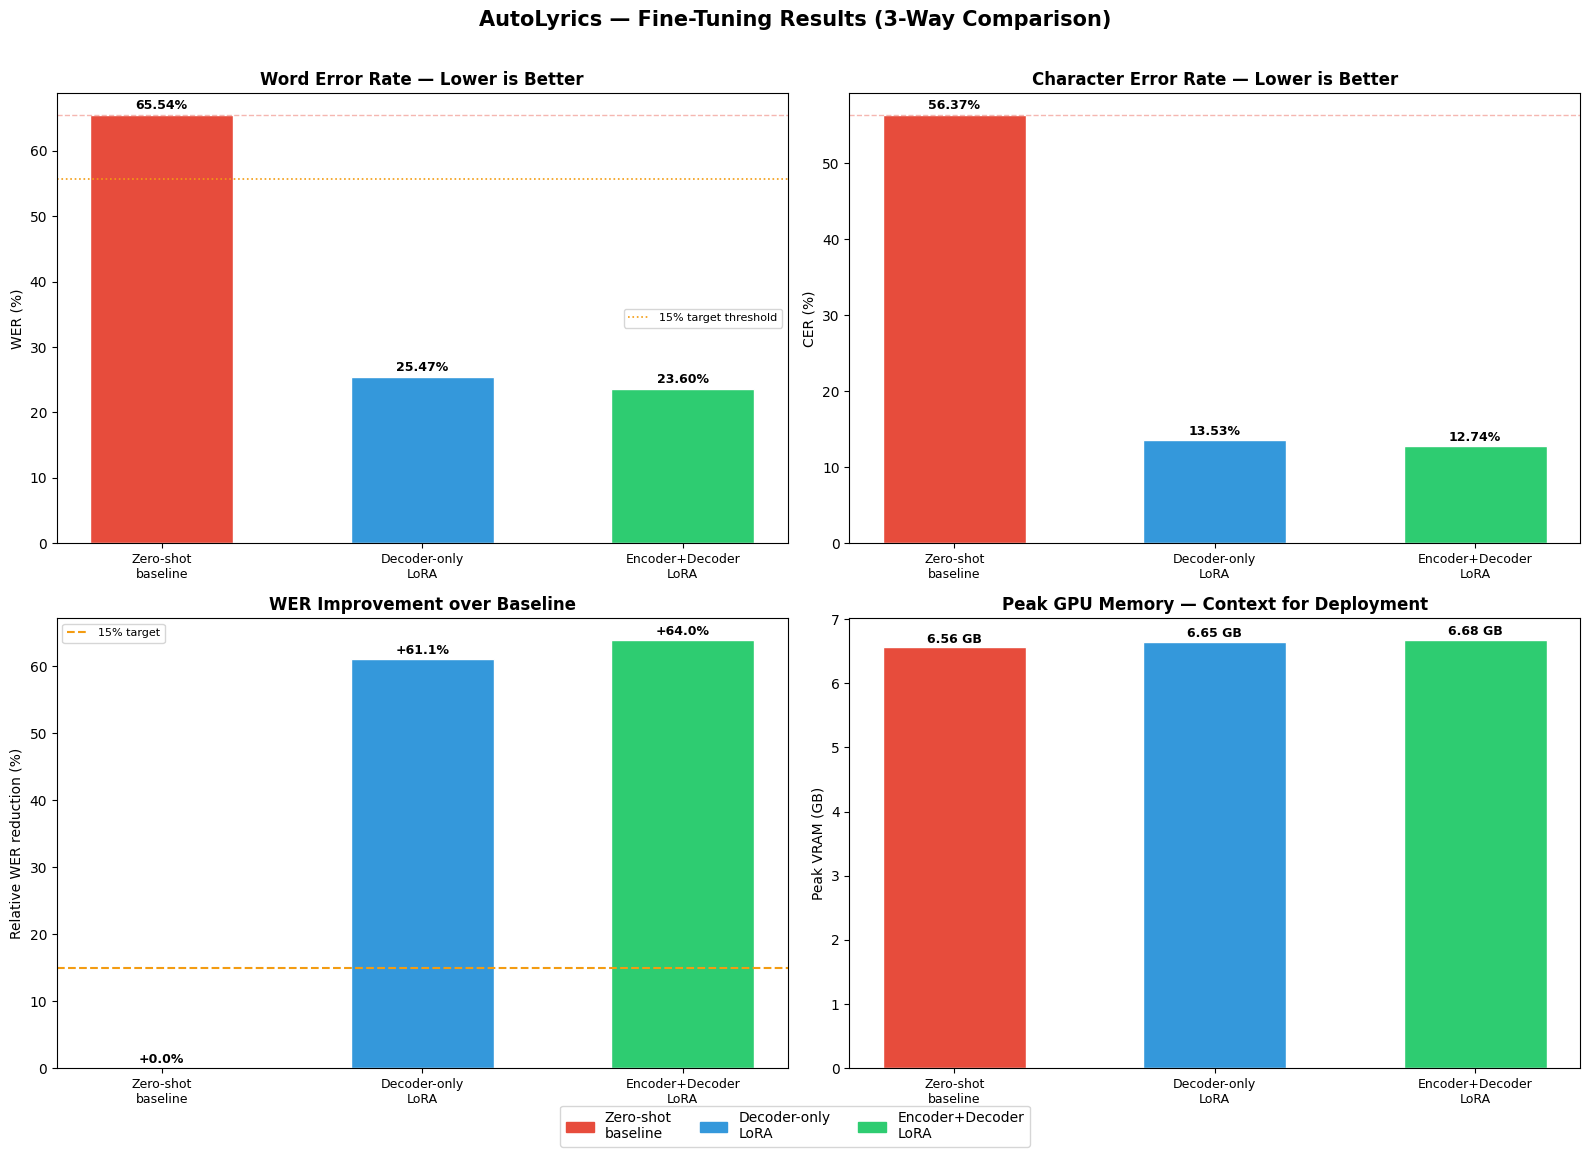

✅ Dashboard saved → /content/results/autolyrics_results_dashboard.png


In [24]:
# 7.3 — Visualisation dashboard (4 plots, 3-way aware)
# ==============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

MODEL_LABELS  = ["Zero-shot\nbaseline", "Decoder-only\nLoRA", "Encoder+Decoder\nLoRA"]
COLORS        = ["#e74c3c", "#3498db", "#2ecc71"]   # red, blue, green

dec_r  = next((r for r in comparison_results if r["experiment"] == "decoder_only"),  None)
enc_r  = next((r for r in comparison_results if r["experiment"] == "encoder_decoder"), None)

wer_vals  = [baseline_results["wer"],
             dec_r["test_wer"]  if dec_r  else 0,
             enc_r["test_wer"]  if enc_r  else 0]
cer_vals  = [baseline_results["cer"],
             dec_r["test_cer"]  if dec_r  else 0,
             enc_r["test_cer"]  if enc_r  else 0]
loss_vals = [None,
             dec_r["train_loss"] if dec_r else 0,
             enc_r["train_loss"] if enc_r else 0]
vram_vals = [baseline_results["peak_vram_gb"],
             dec_r["peak_vram_gb"] if dec_r else 0,
             enc_r["peak_vram_gb"] if enc_r else 0]

x = np.arange(len(MODEL_LABELS))

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("AutoLyrics — Fine-Tuning Results (3-Way Comparison)",
             fontsize=15, fontweight="bold", y=1.01)

# ── Plot 1: WER ───────────────────────────────────────────────
ax = axes[0, 0]
bars = ax.bar(x, wer_vals, color=COLORS, edgecolor="white", width=0.55)
ax.set_xticks(x); ax.set_xticklabels(MODEL_LABELS, fontsize=9)
ax.set_ylabel("WER (%)"); ax.set_title("Word Error Rate — Lower is Better", fontweight="bold")
ax.axhline(baseline_results["wer"], color="#e74c3c", linestyle="--", linewidth=1, alpha=0.4)
ax.axhline(baseline_results["wer"] * 0.85, color="#f39c12", linestyle=":",
           linewidth=1.2, label="15% target threshold")
ax.legend(fontsize=8)
for bar, v in zip(bars, wer_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.4, f"{v:.2f}%",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

# ── Plot 2: CER ───────────────────────────────────────────────
ax = axes[0, 1]
bars = ax.bar(x, cer_vals, color=COLORS, edgecolor="white", width=0.55)
ax.set_xticks(x); ax.set_xticklabels(MODEL_LABELS, fontsize=9)
ax.set_ylabel("CER (%)"); ax.set_title("Character Error Rate — Lower is Better", fontweight="bold")
ax.axhline(baseline_results["cer"], color="#e74c3c", linestyle="--", linewidth=1, alpha=0.4)
for bar, v in zip(bars, cer_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f"{v:.2f}%",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

# ── Plot 3: Relative WER improvement over baseline ───────────
ax = axes[1, 0]
rel_imps = [0.0,
            (baseline_results["wer"] - wer_vals[1]) / baseline_results["wer"] * 100,
            (baseline_results["wer"] - wer_vals[2]) / baseline_results["wer"] * 100]
bar_colors_imp = ["#95a5a6", "#3498db", "#2ecc71"]
bars = ax.bar(x, rel_imps, color=bar_colors_imp, edgecolor="white", width=0.55)
ax.axhline(15, color="#f39c12", linestyle="--", linewidth=1.5, label="15% target")
ax.axhline(0, color="gray", linewidth=0.6)
ax.set_xticks(x); ax.set_xticklabels(MODEL_LABELS, fontsize=9)
ax.set_ylabel("Relative WER reduction (%)"); ax.set_title("WER Improvement over Baseline", fontweight="bold")
ax.legend(fontsize=8)
for bar, v in zip(bars, rel_imps):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f"{v:+.1f}%",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

# ── Plot 4: VRAM usage ────────────────────────────────────────
ax = axes[1, 1]
bars = ax.bar(x, vram_vals, color=COLORS, edgecolor="white", width=0.55)
ax.set_xticks(x); ax.set_xticklabels(MODEL_LABELS, fontsize=9)
ax.set_ylabel("Peak VRAM (GB)"); ax.set_title("Peak GPU Memory — Context for Deployment", fontweight="bold")
for bar, v in zip(bars, vram_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.2f} GB",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

# Shared legend
legend_patches = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORS, MODEL_LABELS)]
fig.legend(handles=legend_patches, loc="lower center", ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
chart_path = RESULTS_DIR / "autolyrics_results_dashboard.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Dashboard saved → {chart_path}")


In [25]:
# 7.4 — Side-by-side predictions: all 3 models per sample
# ==============================================================

# Align all prediction lists to the same reference set
refs = baseline_results["references"]
base_preds = baseline_results["predictions"]

dec_preds = dec_r["predictions"] if dec_r else ["—"] * len(refs)
enc_preds = enc_r["predictions"] if enc_r else ["—"] * len(refs)

n_samples = min(5, len(refs))

print("🎤  SAMPLE PREDICTIONS — All 3 Models\n")
print("=" * 90)

for i in range(n_samples):
    ref  = refs[i]
    base = base_preds[i]
    dec  = dec_preds[i]  if i < len(dec_preds)  else "—"
    enc  = enc_preds[i]  if i < len(enc_preds)  else "—"

    ref_words = set(ref.split())

    def overlap(pred):
        if pred == "—": return 0
        return len(ref_words & set(pred.split())) / max(len(ref_words), 1) * 100

    print(f"  Sample {i+1}  (speaker: {test_samples[i]['speaker']}  |  song: {test_samples[i]['song_id']})")
    print(f"  {'REF':<18}: {ref[:85]}")
    print(f"  {'ZERO-SHOT':<18}: {base[:85]}  [{overlap(base):.0f}% word match]")
    print(f"  {'DECODER-ONLY':<18}: {dec[:85]}  [{overlap(dec):.0f}% word match]")
    print(f"  {'ENC+DEC':<18}: {enc[:85]}  [{overlap(enc):.0f}% word match]")
    print("-" * 90)

# Per-sample WER breakdown (useful for a small test set)
print("\n📊  PER-SAMPLE WER BREAKDOWN\n")
print(f"  {'Sample':<10} {'Speaker':<8} {'Baseline':>10} {'Dec-only':>10} {'Enc+Dec':>10}")
print("  " + "-" * 52)

from jiwer import wer as jwer

for i in range(n_samples):
    ref  = refs[i]
    w_base = jwer(ref, base_preds[i]) * 100
    w_dec  = jwer(ref, dec_preds[i])  * 100 if i < len(dec_preds) and dec_preds[i] != "—" else float("nan")
    w_enc  = jwer(ref, enc_preds[i])  * 100 if i < len(enc_preds) and enc_preds[i] != "—" else float("nan")
    spk    = test_samples[i]["speaker"] if i < len(test_samples) else "—"
    print(f"  {i+1:<10} {spk:<8} {w_base:>9.1f}% {w_dec:>9.1f}% {w_enc:>9.1f}%")

print("\n  Note: Per-sample variance is high with a small test set (LOSO = ~4 samples).")
print("  These numbers show model behaviour per song/speaker, not statistical significance.")

🎤  SAMPLE PREDICTIONS — All 3 Models

  Sample 1  (speaker: ZHIY  |  song: 02)
  REF               : dou, a deer, a female deer, re, a job of golden sun, mi, a name i call myself, far, a
  ZERO-SHOT         : [singing]  [0% word match]
  DECODER-ONLY      : do, a deer, a female deer. re, a job of gold and sun. mi, a name. i call myself. far,  [74% word match]
  ENC+DEC           : do, a deer, a female deer. re, a job of golden sun. mi, a name. i call myself. fire.   [74% word match]
------------------------------------------------------------------------------------------
  Sample 2  (speaker: ZHIY  |  song: 03)
  REF               : dashing through the snow in a one-horse open sleigh, o'er the fields we go laughing a
  ZERO-SHOT         : dashing through the snow in a one-horse open sleigh, o'er the fields we go, laughing   [89% word match]
  DECODER-ONLY      : dashing through the snow in a one-horse open sleigh, o'er the fields we go, laughing   [87% word match]
  ENC+DEC           